# Quantum Teleportation using Qiskit

This notebook implements and verifies the quantum teleportation protocol using Qiskit.

The experiment uses an ideal statevector simulation to examine whether an input quantum state prepared on one qubit is successfully reproduced on a remote qubit using entanglement and coherent quantum operations.

The protocol is tested using several single-qubit input states, and the teleportation fidelity is calculated for each case.

## 1. Introduction

Quantum teleportation is a fundamental protocol in quantum information.

It allows an unknown quantum state to be transferred from one qubit to another using a shared entangled state together with local quantum operations.

The protocol does not physically transmit the quantum state itself. Instead, the information required to reconstruct the state is encoded through the interaction between the input qubit and one half of an entangled Bell pair.

The standard operational protocol contains:

1. Preparation of the input state
2. Creation of an entangled Bell pair
3. Bell-basis measurement
4. Classical communication
5. Conditional correction operations

For this computational experiment, a coherent measurement-free formulation is used. This allows the complete quantum evolution to remain available for statevector analysis and fidelity verification.

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import (
    Statevector,
    partial_trace,
    state_fidelity
)

import numpy as np
import matplotlib.pyplot as plt

## 2. Define Input States

To make the experiment more informative than a single demonstration, the teleportation protocol will be tested with four standard single-qubit states:

- $|0\rangle$
- $|1\rangle$
- $|+\rangle$
- $|-\rangle$

These states include both computational-basis states and superposition states.

In [4]:
input_states = {
    "|0⟩": Statevector.from_label("0"),
    "|1⟩": Statevector.from_label("1"),
    "|+⟩": Statevector.from_label("+"),
    "|−⟩": Statevector.from_label("-"),
}

input_states

{'|0⟩': Statevector([1.+0.j, 0.+0.j],
             dims=(2,)),
 '|1⟩': Statevector([0.+0.j, 1.+0.j],
             dims=(2,)),
 '|+⟩': Statevector([0.70710678+0.j, 0.70710678+0.j],
             dims=(2,)),
 '|−⟩': Statevector([ 0.70710678+0.j, -0.70710678+0.j],
             dims=(2,))}

## 3. Build the Teleportation Circuit

The circuit contains three qubits:

- Qubit 0: input state
- Qubit 1: sender's half of the Bell pair
- Qubit 2: receiver's half of the Bell pair

The circuit uses a coherent formulation of the teleportation protocol.

In [5]:
def create_teleportation_circuit(state_name):
    qc = QuantumCircuit(3)

    # Prepare the input state
    if state_name == "|0⟩":
        pass

    elif state_name == "|1⟩":
        qc.x(0)

    elif state_name == "|+⟩":
        qc.h(0)

    elif state_name == "|−⟩":
        qc.x(0)
        qc.h(0)

    else:
        raise ValueError(f"Unknown state: {state_name}")

    # Create Bell pair between qubits 1 and 2
    qc.h(1)
    qc.cx(1, 2)

    # Bell-basis transformation
    qc.cx(0, 1)
    qc.h(0)

    # Coherent correction operations
    qc.cx(1, 2)
    qc.cz(0, 2)

    return qc

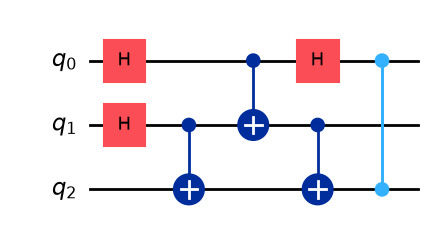

In [6]:
qc = create_teleportation_circuit("|+⟩")

qc.draw("mpl")

## 4. Statevector Simulation

The circuit is simulated using Qiskit's statevector representation.

Because the simulation is ideal and noiseless, the complete quantum state can be examined directly.

In [7]:
def simulate_teleportation(qc):
    return Statevector.from_instruction(qc)

In [8]:
final_state = simulate_teleportation(qc)

final_state

Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))


## 5. Extract the Receiver's State

After the teleportation circuit has been executed, qubits 0 and 1 are traced out.

The resulting reduced density matrix represents the state held by the receiver on qubit 2.

In [9]:
rho_receiver = partial_trace(final_state, [0, 1])

rho_receiver

DensityMatrix([[0.5+0.j, 0.5+0.j],
               [0.5+0.j, 0.5+0.j]],
              dims=(2,))


## 6. Calculate Teleportation Fidelity

The fidelity measures how closely the receiver's state matches the original input state.

For an ideal teleportation protocol, the expected fidelity is:

$$
F \approx 1
$$

Small deviations from exactly 1 can occur because of floating-point numerical precision.

In [10]:
def calculate_fidelity(input_state, receiver_state):
    return state_fidelity(input_state, receiver_state)

In [11]:
initial_state = input_states["|+⟩"]

fidelity = calculate_fidelity(
    initial_state,
    rho_receiver
)

print(f"Teleportation fidelity: {fidelity:.12f}")

Teleportation fidelity: 1.000000000000


## 7. Test Multiple Input States

The protocol is now evaluated for several different input states.

In [12]:
results = []

for state_name, initial_state in input_states.items():
    qc = create_teleportation_circuit(state_name)

    final_state = simulate_teleportation(qc)

    receiver_state = partial_trace(
        final_state,
        [0, 1]
    )

    fidelity = calculate_fidelity(
        initial_state,
        receiver_state
    )

    results.append({
        "State": state_name,
        "Fidelity": fidelity
    })

results

[{'State': '|0⟩', 'Fidelity': 0.9999999999999996},
 {'State': '|1⟩', 'Fidelity': 0.9999999999999996},
 {'State': '|+⟩', 'Fidelity': 0.9999999999999993},
 {'State': '|−⟩', 'Fidelity': 0.9999999999999993}]

In [13]:
for result in results:
    print(
        f"{result['State']:>4}  "
        f"→ Fidelity = {result['Fidelity']:.12f}"
    )

 |0⟩  → Fidelity = 1.000000000000
 |1⟩  → Fidelity = 1.000000000000
 |+⟩  → Fidelity = 1.000000000000
 |−⟩  → Fidelity = 1.000000000000


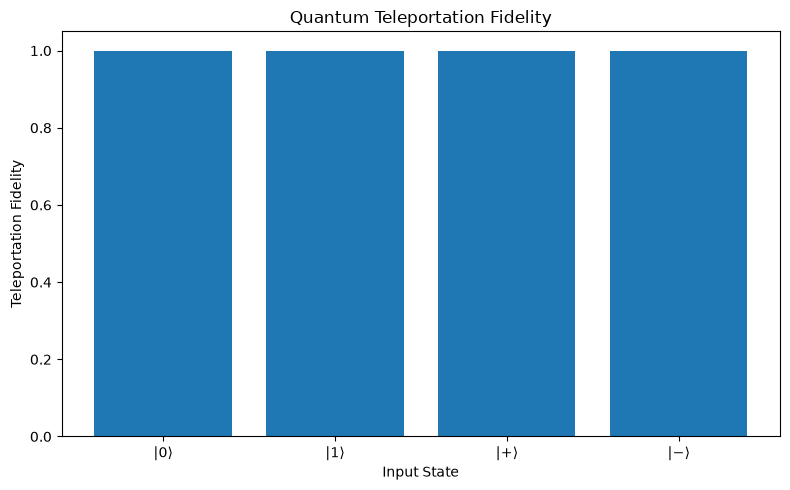

In [14]:
state_names = [result["State"] for result in results]
fidelities = [result["Fidelity"] for result in results]

plt.figure(figsize=(8, 5))

plt.bar(state_names, fidelities)

plt.ylim(0, 1.05)
plt.xlabel("Input State")
plt.ylabel("Teleportation Fidelity")
plt.title("Quantum Teleportation Fidelity")

plt.tight_layout()
plt.show()

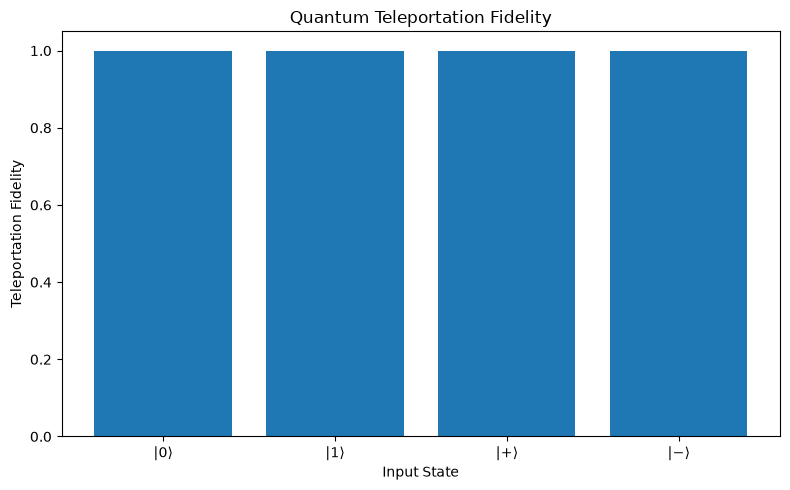

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(state_names, fidelities)

plt.ylim(0, 1.05)
plt.xlabel("Input State")
plt.ylabel("Teleportation Fidelity")
plt.title("Quantum Teleportation Fidelity")

plt.tight_layout()

plt.savefig(
    "results/fidelity_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()